Goal: go from the HMF to the UVLF by parameterizing each step in the process \
Following Shen+23

In [2]:
import numpy as np
import zeus21
from classy import Class
import cosmo_calc
import importlib

In [3]:
z = 3

# HMF

In [8]:
M_vals = np.logspace(7, 14, 100)
params, HMFintclass = cosmo_calc.hmf_zeus(z = z)
hmf = HMFintclass.HMF_int(M_vals, z)

In [32]:
params

{'Omega_b': 0.04867734979810887,
 'Omega_m': 0.30988304304812053,
 'Omega_L': 0.6900259954953076,
 'h': 0.6727}

Text(0.5, 1.0, 'HMF, $z=3$')

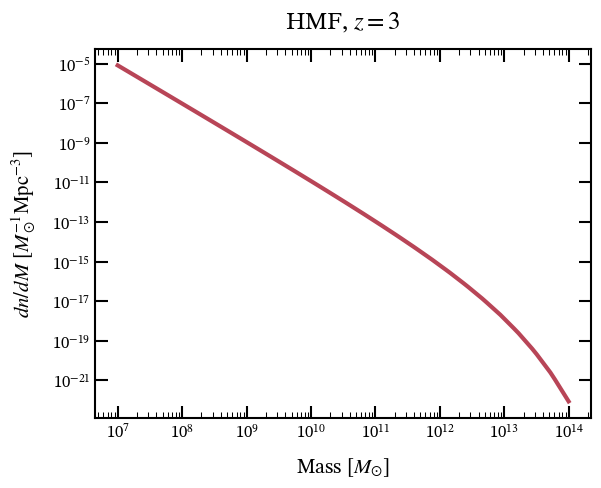

In [15]:
fig, ax = plt.subplots()
ax.loglog(M_vals, hmf)
ax.set_ylabel(r'$dn/dM$ [$M_\odot^{-1}\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_title(f'HMF, $z={z}$')

# Mass accretion

In [34]:
def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

In [35]:
m_dots = calc_M_dot(M_vals, params, z)

Text(0.5, 1.0, 'Mass accretion rate')

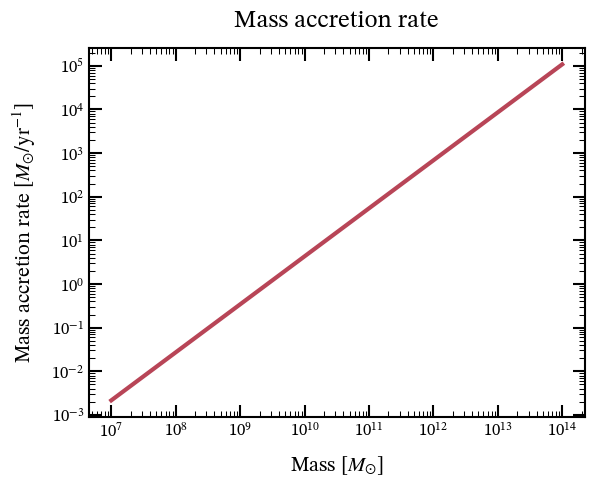

In [103]:
fig, ax = plt.subplots()
ax.loglog(M_vals, m_dots)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'Mass accretion rate [$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('Mass accretion rate')

In [119]:
def calc_SFE(M_h, eps_0 = 0.1, M_0 = 1e12, alpha = 0.6, beta = 0.5):
    return 2*eps_0/((M_h/M_0)**-alpha+(M_h/M_0)**beta)

In [120]:
SFE = calc_SFE(M_vals)

Text(0.5, 1.0, 'SFE')

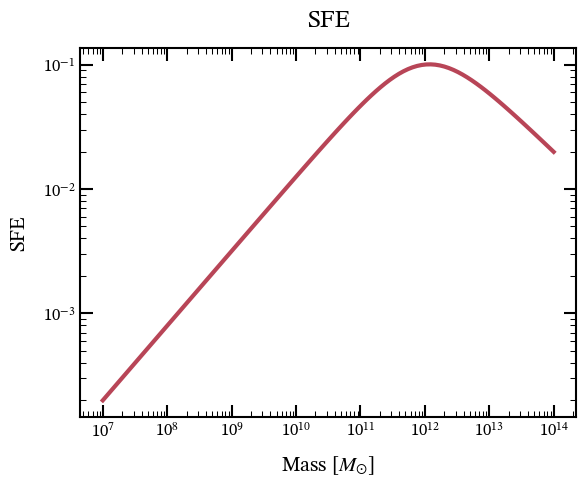

In [127]:
fig, ax = plt.subplots()
ax.loglog(M_vals, SFE)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFE')
ax.set_title('SFE')

In [123]:
def calc_SFR(M_h, params, z=0):
    fb = params['Omega_b']/params['Omega_m']
    M_dot = calc_M_dot(M_h, params, z)
    eps_star = calc_SFE(M_h)
    return fb*M_dot*eps_star

In [124]:
sfrs = calc_SFR(M_vals, params, z)

Text(0.5, 1.0, 'SFR')

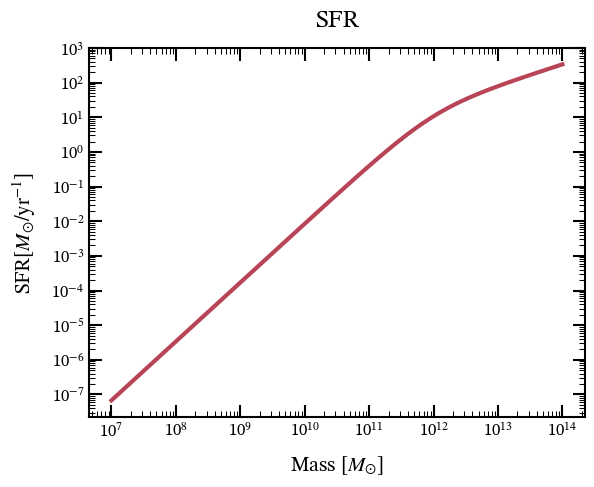

In [125]:
fig, ax = plt.subplots()
ax.loglog(M_vals, sfrs)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_ylabel(r'SFR[$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_title('SFR')

In [172]:
def calc_L_UV(M_h, params, z=0, Kappa_UV = 1.15e-28):
    SFR = calc_SFR(M_h, params, z)
    return SFR/Kappa_UV

def calc_M_UV(M_h, params, z=0):
    L_UV = calc_L_UV(M_h, params, z)
    M_UV = 51.63-(2.5*np.log10(L_UV)) # Same as Zeus

    return M_UV

In [173]:
L_UV = calc_L_UV(M_vals, params, z)
M_UV = calc_M_UV(M_vals, params, z)

In [174]:
51.6-(21/0.4)

-0.8999999999999986

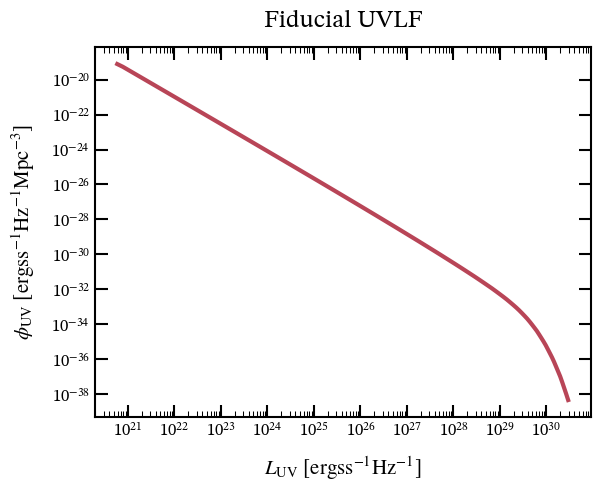

In [190]:
fig, ax = plt.subplots()
ax.loglog(L_UV, hmf*np.gradient(M_vals, L_UV))
ax.set_xlabel(r'$L_{\rm{UV}}$ [$\rm{ergs} \rm{s}^{-1} \rm{Hz}^{-1}$]')
ax.set_ylabel(r'$\phi_{\rm{UV}}$ [$\rm{ergs} \rm{s}^{-1} \rm{Hz}^{-1} \rm{Mpc}^{-3}$]')
ax.set_title('Fiducial UVLF')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/fid_UVLF.png', bbox_inches='tight')

Text(0.5, 1.0, 'Checking L -> mag conversion')

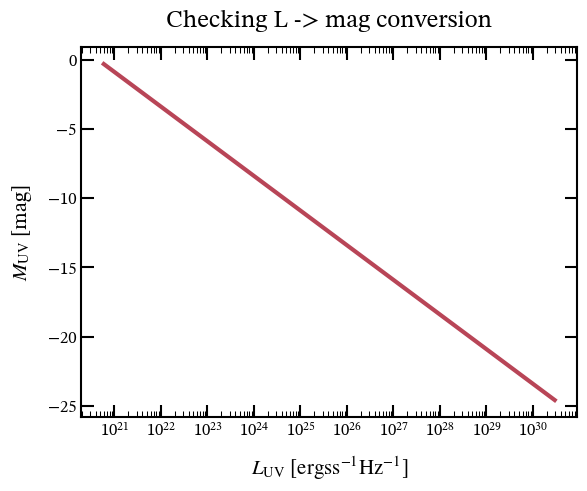

In [163]:
fig, ax = plt.subplots()
ax.plot(L_UV, M_UV)
ax.set_xscale('log')
ax.set_xlabel(r'$L_{\rm{UV}}$ [$\rm{ergs} \rm{s}^{-1} \rm{Hz}^{-1}$]')
ax.set_ylabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_title('Checking L -> mag conversion')

Text(0.5, 1.0, 'Magnitude vs. halo mass')

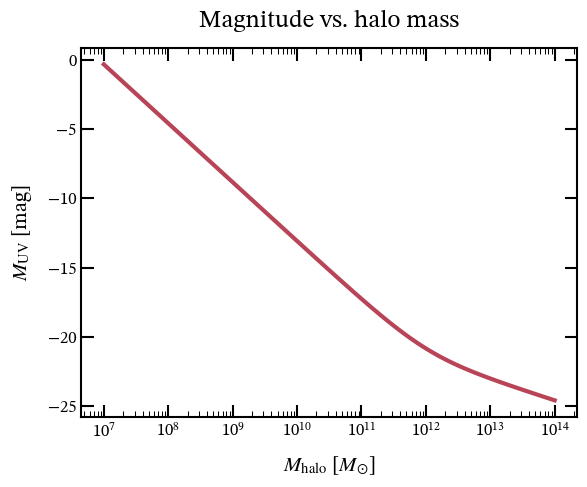

In [165]:
fig, ax = plt.subplots()
ax.plot(M_vals, M_UV)
ax.set_xscale('log')
ax.set_xlabel(r'$M_{\rm{halo}}$ [$M_{\odot}$]')
ax.set_ylabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_title('Magnitude vs. halo mass')

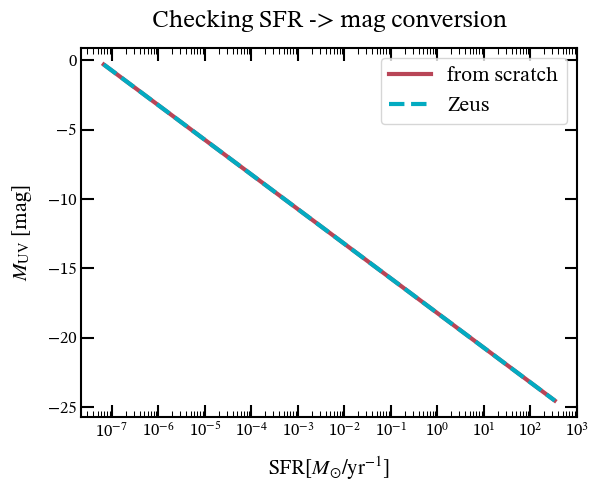

In [192]:
# Check SFR to magnitude converison
fig, ax = plt.subplots()
ax.plot(sfrs, M_UV, label = 'from scratch')
ax.plot(sfrs, zeus21.UVLFs.MUV_of_SFR(sfrs, 1.15e-28), linestyle = '--', label = 'Zeus')
ax.set_xscale('log')
ax.set_xlabel(r'SFR[$M_{\odot}/\rm{yr}^{-1}$]')
ax.set_ylabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_title('Checking SFR -> mag conversion')
ax.legend()

fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/sfr_mag.png', bbox_inches='tight')

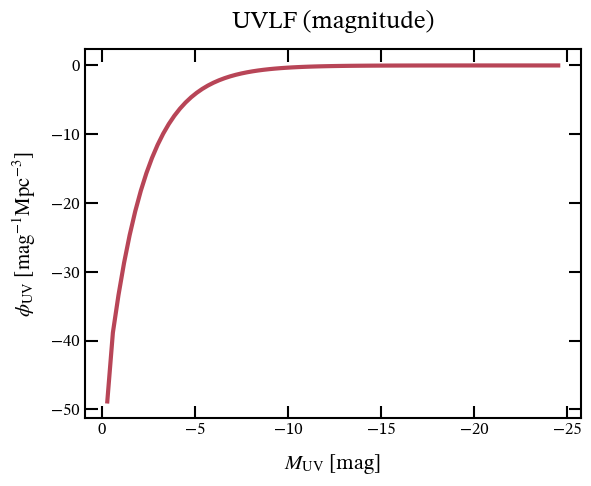

In [191]:
fig, ax = plt.subplots()
ax.plot(M_UV, hmf*np.gradient(M_vals, M_UV))
ax.invert_xaxis()
ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
ax.set_ylabel(r'$\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$]')
ax.set_title('UVLF (magnitude)')

#fig.savefig('/Users/eb35267/Desktop/figures/ongoing/problems/UVLF_mag.png', bbox_inches = 'tight')